In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
df_final = pd.read_csv("cafba_sweep_results.csv", index_col=0)

In [16]:
df_final

,w_c,growth_rate,phi_C,phi_E,phi_R,flux_PFK,flux_EDD,flux_glc
0,0.000000,0.587059,0.000000,0.384787,0.165800,9.206724,0.0,10.000000
1,0.000102,0.586033,0.001020,0.383940,0.165626,9.208111,0.0,10.000000
2,0.000210,0.584945,0.002102,0.383043,0.165441,9.209581,0.0,10.000000
3,0.000331,0.583734,0.003306,0.382043,0.165235,9.211217,0.0,10.000000
4,0.000469,0.582338,0.004693,0.380892,0.164997,9.213103,0.0,10.000000
...,...,...,...,...,...,...,...,...
95,0.884379,0.038562,0.450461,0.027022,0.072556,0.479009,0.0,0.509353
96,0.912397,0.037458,0.451422,0.026248,0.072368,0.465290,0.0,0.494765
97,0.941002,0.036394,0.452347,0.025502,0.072187,0.452071,0.0,0.480708
98,0.970201,0.035368,0.453240,0.024783,0.072013,0.439330,0.0,0.467160


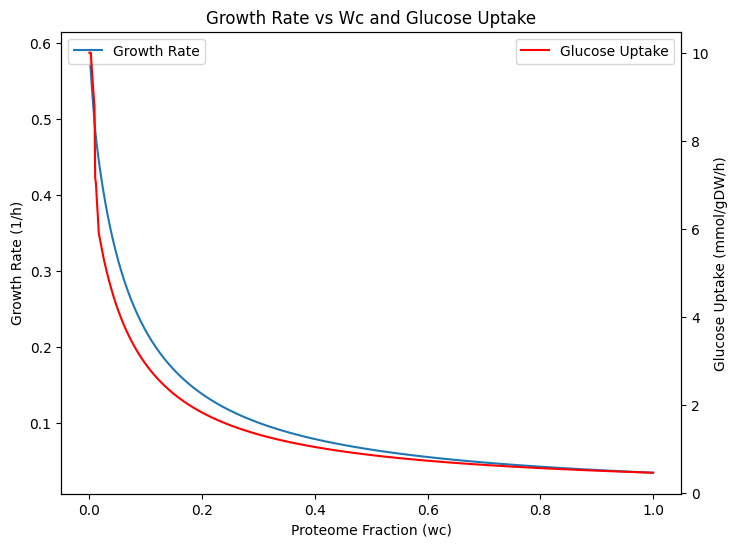

In [17]:
# Plot wc versus growth rate and the glucose uptake flux on the same graph with two y axis (growth rate on left, glucose uptake on right)
plt.figure(figsize=(8, 6))
ax1 = plt.gca()
ax2 = ax1.twinx()

ax1.plot(df_final['w_c'], df_final['growth_rate'], label='Growth Rate')
ax2.plot(df_final['w_c'], df_final['flux_glc'], label='Glucose Uptake', color='red')

ax1.set_xlabel('Proteome Fraction (wc)')
ax1.set_ylabel('Growth Rate (1/h)')
ax2.set_ylabel('Glucose Uptake (mmol/gDW/h)')

# Add legends
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.title('Growth Rate vs Wc and Glucose Uptake')

# Save the plot
plt.savefig("cafba_wc_growth_rate.png", dpi=300)
plt.show()

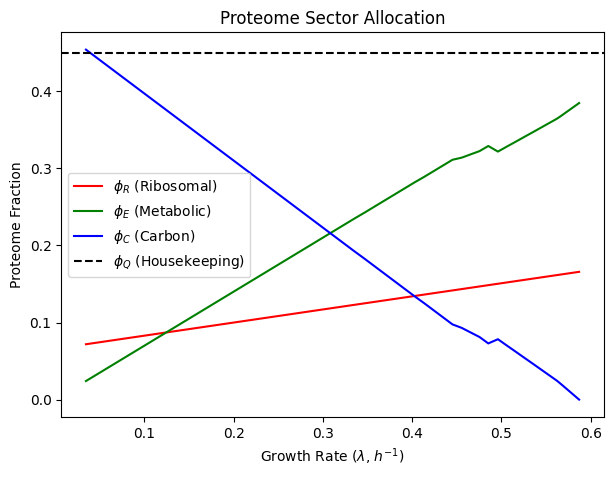

In [18]:
plt.figure(figsize=(7, 5))
plt.plot(df_final['growth_rate'], df_final['phi_R'], color='red', label='$\phi_R$ (Ribosomal)')
plt.plot(df_final['growth_rate'], df_final['phi_E'], color='green', label='$\phi_E$ (Metabolic)')
plt.plot(df_final['growth_rate'], df_final['phi_C'], color='blue', label='$\phi_C$ (Carbon)')
plt.axhline(y=PHI_Q, color='black', linestyle='--', label='$\phi_Q$ (Housekeeping)')
plt.xlabel('Growth Rate ($\lambda$, $h^{-1}$)')
plt.ylabel('Proteome Fraction')
plt.legend()
plt.title('Proteome Sector Allocation')

# Save the plot
plt.savefig("cafba_proteome_allocation.png", dpi=300)
plt.show()

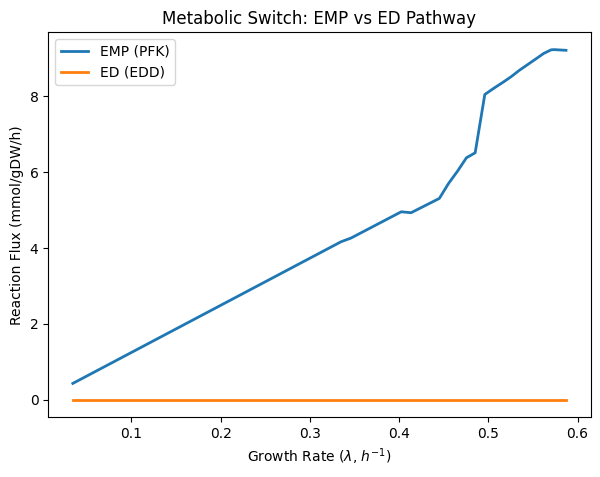

In [19]:
plt.figure(figsize=(7, 5))
plt.plot(df_final['growth_rate'], df_final['flux_PFK'], label='EMP (PFK)', linewidth=2)
plt.plot(df_final['growth_rate'], df_final['flux_EDD'], label='ED (EDD)', linewidth=2)
plt.xlabel('Growth Rate ($\lambda$, $h^{-1}$)')
plt.ylabel('Reaction Flux (mmol/gDW/h)')
plt.title('Metabolic Switch: EMP vs ED Pathway')
plt.legend()

# Save the plot
plt.savefig("cafba_emp_ed_fluxes.png", dpi=300)
plt.show()